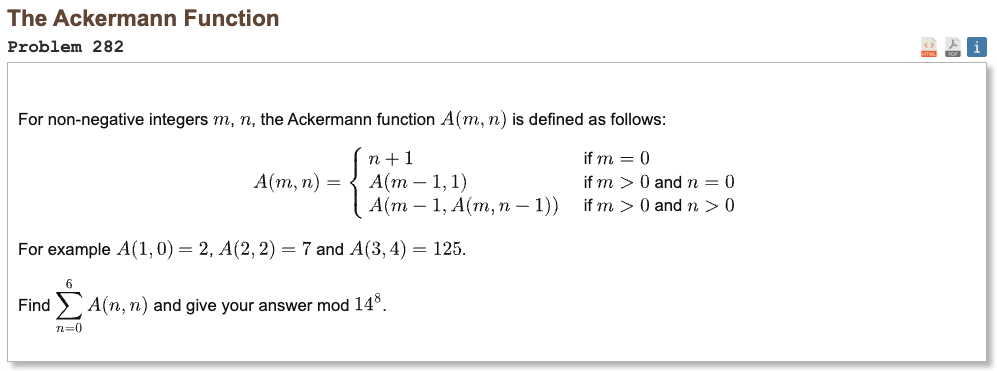

## Initial approach

* first write out the small diagonal values directly, because the first few cases stay tiny and easy
* after that, notice the function quickly turns into repeated powers of 2, then repeated power towers of 2, and then even higher layers built from the same idea
* the only thing we really need is each huge value modulo the final modulus, so we never try to build the full number
* for the power tower part, reduce the exponent through a chain of smaller moduli, using totients to keep the recursion manageable
* because the modulus shares factors with 2, you also need a small check that tells you when an exponent is already large enough and must be lifted before taking the power
* the value for the fourth diagonal term comes from a tower of height 7
* the fifth and sixth diagonal terms are so enormous that they both land on the same stabilized tower value modulo the target modulus
* add all seven diagonal terms and take the final remainder

In [1]:
from functools import lru_cache

def phi(n):
    result = n
    x = n
    p = 2
    while p * p <= x:
        if x % p == 0:
            while x % p == 0:
                x //= p
            result -= result // p
        p += 1
    if x > 1:
        result -= result // x
    return result

def big_enough_tetration(height, limit):
    if limit <= 2:
        return True
    value = 2
    if height == 1:
        return value >= limit
    for _ in range(2, height + 1):
        if value >= 60:
            return True
        value = 2 ** value
        if value >= limit:
            return True
    return value >= limit

@lru_cache(None)
def tetration_mod(height, mod):
    if mod == 1:
        return 0
    if height == 1:
        return 2 % mod
    ph = phi(mod)
    exp = tetration_mod(height - 1, ph)
    if big_enough_tetration(height - 1, ph):
        exp += ph
    return pow(2, exp, mod)

def solve():
    mod = 14 ** 8
    values = [1, 3, 7, 61]
    values.append((tetration_mod(7, mod) - 3) % mod)
    stable = (tetration_mod(10, mod) - 3) % mod
    values.append(stable)
    values.append(stable)
    result = sum(values) % mod
    return result

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 1098988351
CPU times: user 320 μs, sys: 50 μs, total: 370 μs
Wall time: 349 μs
